# Beyond Travel Time - Dissertation Prototype
## Notebook 3 of 3: Route Scoring & Multi-Objective Optimization (Objectives 3 & 4)
**Student:** Azain Ayub (250467941)
---

> **Prerequisites:** run `dissertation_data.ipynb` and `dissertation_sr.ipynb` first.
This notebook expects `sr_models.pkl` and `chicago_hist_averages.csv` to already be sitting in `/content/`.

The evaluation here covers 32 journeys across 9 departure times (288 scenarios in total), scored against 9 weight vectors ranging from "fastest" to "cleanest".
This sample gives a representative picture of how the router behaves across the city rather than on a handful of hand-picked cases.

A couple of things worth knowing before running the whole notebook top to bottom:

- **It takes a while.** 32 journeys x 9 weight vectors x 9 times works out to 2,592 individual route searches, and edge scoring alone runs 9 times (roughly 70-90s each), so expect around 10-13 minutes before route search even starts, on top of downloading a larger road network for the wider bounding box.
- **Not every edge in the newly-added area has a real sensor match.** `chicago_edge_segment_matches.csv` (built in `dissertation_data.ipynb`, Section 8) was generated using the original, smaller bounding box, so edges north of Rogers Park or south of Pullman/Roseland fall back to synthetic prediction rather than a genuine per-segment lookup. That's the intended fallback behaviour, not a bug, but it does mean coverage is patchier for journeys that pass through those areas. Re-running Section 8 of the data notebook with the wider bbox would fix this if full coverage matters.

### What this notebook covers
| Section | Content | Objective |
|---------|---------|-----------|
| 1 | Setup + load SR models | - |
| 2 | Load OSMnx Chicago road network | - |
| 3 | Hybrid temporal x spatial pollution model | - |
| 4 | Experimental design - 32 journeys x 9 departure times | - |
| 5 | Route search across all 288 scenarios | **O3: >= 3 distinct routes** |
| 6 | Results table + Pareto front visualizations | - |
| 7 | Evaluation vs Dijkstra baseline (aggregated) | **O4: pollution (down) vs time (up)** |
| 8 | Sensitivity analysis | - |
| 9 | Map visualiaation (all journeys) | - |
| 10 | Summary | - |

---
## Section 1 - Setup & Load SR Models

In [1]:
# Core stack for this notebook: OSMnx/NetworkX for the road graph and
# routing, Folium for the interactive map, DEAP for compiling the SR
# expressions, scikit-learn as a dependency of the SR pipeline.
!pip install -q osmnx networkx folium deap scikit-learn
print('Libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 15.0 MB/s eta 0:00:00
Libraries installed.


In [2]:
import pandas as pd
import numpy as np
import pickle, json, operator, random, time, os, warnings
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import folium
from deap import base, creator, gp  # needed to compile the pickled SR expressions

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
print('Imports ready. OSMnx version:', ox.__version__)

Imports ready. OSMnx version: 2.1.1


### Re-declaring the SR primitive functions

This step can't be skipped. The trained models were pickled from a different notebook session, and Python's `pickle` only stores a *reference* (module + name) to each function used inside the DEAP primitive set, not its actual
code. If these functions aren't already defined in this session before `sr_models.pkl` is loaded, unpickling fails.

In [3]:
# Must be IDENTICAL (same names) to the functions defined in dissertation_sr.ipynb,
# otherwise pickle can't resolve the references stored inside the DEAP pset.
def rand_const():
    return round(random.uniform(-10, 10), 2)

def _pdiv(a, b):
    # Protected division - avoids blowing up on a near-zero denominator
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    safe_b = np.where(np.abs(b) > 1e-6, b, 1.0)
    result = a / safe_b
    return np.where(np.abs(b) > 1e-6, result, 1.0)

def _psqrt(x):
    # Protected sqrt - takes abs first so negative inputs don't produce NaN
    return np.sqrt(np.abs(np.asarray(x, dtype=float)))

def _plog(x):
    # Protected log - abs + small epsilon keeps zero/negative inputs finite
    return np.log(np.abs(np.asarray(x, dtype=float)) + 1e-6)

print('SR primitive functions re-declared - pickle can now resolve them.')

SR primitive functions re-declared - pickle can now resolve them.


In [5]:
MODELS_PATH = '/content/sr_models.pkl'
HIST_AVG_PATH = '/content/chicago_hist_averages.csv'

print('Loading trained SR models .......')
with open(MODELS_PATH, 'rb') as f:
    models = pickle.load(f)

# Each target (speed, NO2, PM2.5) has its own best individual + its own
# primitive set, since they were evolved separately in dissertation_sr.ipynb
best_spd, pset_spd = models['best_spd'], models['pset_spd']
best_no2, pset_no2 = models['best_no2'], models['pset_no2']
best_pm25, pset_pm25 = models['best_pm25'], models['pset_pm25']
SPEED_FEATS = models['SPEED_FEATS']
NO2_FEATS = models['NO2_FEATS']
PM25_FEATS = models['PM25_FEATS']

# Compile the GP expression trees into callable functions
fn_spd = gp.compile(expr=best_spd, pset=pset_spd)
fn_no2 = gp.compile(expr=best_no2, pset=pset_no2)
fn_pm25 = gp.compile(expr=best_pm25, pset=pset_pm25)

print('Models loaded and compiled successfully.')
print(f' Speed features ({len(SPEED_FEATS)}): {SPEED_FEATS}')
print(f' NO2 features ({len(NO2_FEATS)}): {NO2_FEATS}')
print(f' PM2.5 features ({len(PM25_FEATS)}): {PM25_FEATS}')

print('\nLoading historical averages (city-wide fallback + per-segment lookup).......')
df_hist = pd.read_csv(HIST_AVG_PATH, dtype={'id': str})
print(f' df_hist id dtype: {df_hist["id"].dtype} (forced to string)')

# City-wide average lag values per (hour, day-of-week) - used as the fallback
# whenever an edge has no matched segment of its own
city_avg = (df_hist.groupby(['hour','dayofweek'])
            .agg(spd_lag1_avg=('spd_lag1_avg','mean'),
                 no2_lag1_avg=('no2_lag1_avg','mean'),
                 pm25_lag1_avg=('pm25_lag1_avg','mean'))
            .reset_index())
print(f' City-wide averages: {len(city_avg)} (hour, dayofweek) combinations')
display(city_avg.head())

Loading trained SR models .......
Models loaded and compiled successfully.
 Speed features (12): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1', 'pm25_lag1']
 NO2 features (11): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1']
 PM2.5 features (12): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1', 'pm25_lag1']

Loading historical averages (city-wide fallback + per-segment lookup).......
 df_hist id dtype: object (forced to string)
 City-wide averages: 168 (hour, dayofweek) combinations


,hour,dayofweek,spd_lag1_avg,no2_lag1_avg,pm25_lag1_avg
0,0,0,42.446550,12.933615,7.375216
1,0,1,41.699810,42.337428,12.568477
2,0,2,41.828033,20.257894,7.094826
3,0,3,42.652026,12.477765,2.035153
4,0,4,42.850210,21.040211,7.713468


---
## Section 2 - OSMnx Chicago Road Network

Downloads the Chicago drive network and assigns free-flow speeds and travel times to every edge, using OSM's own road classification (`highway` tag) and `maxspeed` data where it's available.

In [6]:
# Using an explicit bounding box here instead of ox.graph_from_place('Chicago,
# Illinois, USA', .......). O'Hare is a narrow administrative exclave of the city,
# connected to the rest of Chicago by a thin corridor, and graph_from_place's
# polygon doesn't reliably include the airport's own road network - routes to
# O'Hare were snapping to a node about 4.4km short of the real destination.
# An explicit bbox covering all the journeys' coordinates (plus a 3km buffer)
# sidesteps the administrative-boundary question entirely.
# The box below is expanded north/south from the original version to also
# cover Rogers Park in the far north and Pullman/Roseland in the far south,
# which fell outside the smaller box used for the first 8 journeys.
BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH = -87.9373, 41.6625, -87.5607, 42.0395

print('Downloading Chicago-area road network from OSMnx (explicit bbox) .........')
print(f' bbox = ({BBOX_WEST}, {BBOX_SOUTH}, {BBOX_EAST}, {BBOX_NORTH})')
G = ox.graph_from_bbox((BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH),
                        network_type='drive', simplify=True)
print(f' Nodes: {len(G.nodes):,} | Edges: {len(G.edges):,}')

# Restrict to the largest strongly-connected component. Drive-network
# extracts can contain small disconnected fragments with no path to/from the
# rest of the city - this guarantees every origin/destination pair picked
# later is actually reachable from one another.
n_before = len(G.nodes)
G = ox.truncate.largest_component(G, strongly=True)
print(f'Largest connected component: {len(G.nodes):,} nodes '
      f'(removed {n_before - len(G.nodes):,} disconnected nodes)')

print('Assigning free-flow speeds and travel times .........')
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

nodes, edges = ox.graph_to_gdfs(G)
road_types = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
print('\nRoad type distribution:')
print(road_types.value_counts().head(10).to_string())
print(f'\nFree-flow speed range: {edges["speed_kph"].min():.0f} - {edges["speed_kph"].max():.0f} km/h')

# Quick check that the O'Hare fix actually worked - nearest node to the
# airport's real coordinate should now be close by, not kilometres away
_ohare_node = ox.distance.nearest_nodes(G, -87.9073, 41.9742)
_dist_check = ox.distance.great_circle(41.9742, -87.9073, G.nodes[_ohare_node]["y"], G.nodes[_ohare_node]["x"])
print(f"\nO'Hare coordinate check: nearest node is {_dist_check:.0f}m away "
      f"(should be well under 500m now)")

 bbox = (-87.9373, 41.6625, -87.5607, 42.0395)
 Nodes: 52,273 | Edges: 141,858
Largest connected component: 52,013 nodes (removed 260 disconnected nodes)
Assigning free-flow speeds and travel times .........

Road type distribution:
highway
residential       96321
secondary         20243
tertiary          15229
primary            5058
unclassified       1823
motorway_link       928
motorway            722
primary_link        259
secondary_link      245
trunk               207

Free-flow speed range: 8 - 113 km/h

O'Hare coordinate check: nearest node is 370m away (should be well under 500m now)


---
## Section 3 - Load Precomputed Edge-to-Segment Matches + Per-Edge Prediction

The spatial join between OSMnx edges and Chicago Traffic Tracker segments now happens in `dissertation_data.ipynb` (Section 8), as part of data preparation - that's what satisfies Objective 1's "more than 80% matching between road segments, traffic levels, and pollution measurements" requirement. This
notebook just loads the resulting match table (`chicago_edge_segment_matches.csv`) and uses the trained SR expressions to predict per edge: a genuine call for edges with a real match, and the same real-data-informed synthetic sampling as before for edges without one.

**Requires:** `chicago_edge_segment_matches.csv` in `/content/` (produced by
Section 8 of the data notebook).

In [7]:
# Step 1: load the precomputed edge-to-segment match table
EDGE_MATCHES_PATH = '/content/chicago_edge_segment_matches.csv'
df_edge_matches = pd.read_csv(
    EDGE_MATCHES_PATH,
    dtype={'edge_u': 'int64', 'edge_v': 'int64', 'edge_k': 'int64', 'matched_segment_id': str})
print(f'Loaded {len(df_edge_matches):,} precomputed edge-to-segment matches')

n_genuine = df_edge_matches['matched_segment_id'].notna().sum()
match_rate = n_genuine / len(df_edge_matches) * 100
print(f' Genuinely matched (real sensor-derived history): {n_genuine:,} '
      f'({match_rate:.1f}%)')
print(f' Remaining edges use synthetic sampling (below), same as before.')

# Attach the match directly onto each graph edge. No BallTree needed here -
# the spatial join already happened once, in the data notebook.
edge_match_lookup = df_edge_matches.set_index(['edge_u','edge_v','edge_k'])['matched_segment_id']
_n_attached = 0
for u, v, k, d in G.edges(keys=True, data=True):
    try:
        seg_id = edge_match_lookup.loc[(u, v, k)]
        d['matched_segment_id'] = seg_id if pd.notna(seg_id) else None
    except KeyError:
        # Edge exists in this session's graph but wasn't in the precomputed
        # table (bboxes can drift slightly between runs/OSM updates) -
        # treat it the same as an unmatched edge and fall back to synthetic.
        d['matched_segment_id'] = None
    if d['matched_segment_id']:
        _n_attached += 1
print(f' Attached to current graph: {_n_attached:,} / {len(G.edges):,} edges')

def get_road_type(highway_val):
    # 'highway' can be a single tag or a list of tags on OSMnx edges - just
    # take the first one for classification purposes
    return highway_val[0] if isinstance(highway_val, list) else highway_val

# Step 2: per-segment historical average lookup
hist_lookup = df_hist.set_index(['id','hour','dayofweek'])

def get_segment_lag(segment_id, hour, dayofweek):
    """Real historical average for a specific matched segment, if available."""
    try:
        row = hist_lookup.loc[(segment_id, hour, dayofweek)]
        row = row.iloc[0] if isinstance(row, pd.DataFrame) else row
        return float(row['spd_lag1_avg']), float(row['no2_lag1_avg']), float(row['pm25_lag1_avg'])
    except KeyError:
        return None

# Real-data-derived variability (std), computed only from segments with
# genuine sensor history. Used to sample synthetic values rather than assign
# one identical deterministic number to every edge of a given road type -
# same approach already used for the Objective 1 AQ gap-fill.
real_aq_segment_ids = set(df_edge_matches['matched_segment_id'].dropna())
real_df_hist = df_hist[df_hist['id'].isin(real_aq_segment_ids)]
real_variability = (real_df_hist.groupby(['hour','dayofweek'])
                    .agg(no2_std=('no2_lag1_avg','std'), pm25_std=('pm25_lag1_avg','std'))
                    .reset_index())
_global_no2_std  = real_variability['no2_std'].mean()
_global_pm25_std = real_variability['pm25_std'].mean()
real_variability['no2_std'] = real_variability['no2_std'].fillna(_global_no2_std)
real_variability['pm25_std'] = real_variability['pm25_std'].fillna(_global_pm25_std)
_var_lookup = real_variability.set_index(['hour','dayofweek'])

def get_real_std(hour, dayofweek):
    try:
        row = _var_lookup.loc[(hour, dayofweek)]
        return float(row['no2_std']), float(row['pm25_std'])
    except KeyError:
        return _global_no2_std, _global_pm25_std

print(f'\nReal-data variability computed from {len(real_aq_segment_ids)} genuinely '
      f'real segments: mean NO2 std={_global_no2_std:.2f}, mean PM2.5 std={_global_pm25_std:.2f}')

# Road-type multipliers for the synthetic fallback path.
#
# Earlier attempt applied this multiplier to the SR model's INPUT feature
# (no2_lag1) before calling fn_no2. That caused two problems: the model was
# being fed values wildly outside its training distribution (150-270 ug/m3
# vs real no2_lag1 values under ~50), and pushing the multiplier up mostly
# just drove values into the [0,150] output clip ceiling rather than adding
# real differentiation between road types.
#
# Fixed by applying the multiplier to the SR model's OUTPUT instead, after
# calling it with the realistic, in-distribution baseline, and by tuning the
# curve so every road type stays clear of the clip ceiling even at the
# highest observed city-wide baseline. This gets its spread mostly by
# pushing the low end (residential, living_street) down rather than pushing
# motorway up towards the ceiling, since there's no equivalent risk of
# clipping near zero. Final spread: ~15x between motorway and living_street.
FALLBACK_MULT = {
    'motorway': 2.502, 'motorway_link': 1.849, 'trunk': 2.088, 'trunk_link': 1.612,
    'primary': 1.265, 'primary_link': 0.983, 'secondary': 0.744, 'secondary_link': 0.618,
    'tertiary': 0.426, 'tertiary_link': 0.378, 'residential': 0.088, 'living_street': 0.027,
    'unclassified': 0.357, 'service': 0.075, 'busway': 0.977,
}
DEFAULT_FALLBACK_MULT = 0.426

def predict_edge_genuine(matched_segment_id, hour, dayofweek, month, road_type=None, edge_seed=0):
    """
    Genuine per-edge SR prediction where a real segment match exists (from
    the precomputed table built in dissertation_data.ipynb). Where it
    doesn't, samples a synthetic value from the real segments' own
    distribution (mean adjusted by road type, spread from real std),
    deterministic per edge so results are reproducible across re-runs.
    """
    is_weekend = int(dayofweek >= 5)
    is_rush = int(hour in [7,8,9,17,18,19])
    hour_sin = np.sin(2*np.pi*hour/24); hour_cos = np.cos(2*np.pi*hour/24)
    dow_sin = np.sin(2*np.pi*dayofweek/7); dow_cos = np.cos(2*np.pi*dayofweek/7)

    source = 'synthetic'
    seg_lag = get_segment_lag(matched_segment_id, hour, dayofweek) if matched_segment_id else None
    if seg_lag is not None:
        # Genuine match - use that segment's own historical averages
        spd_avg, no2_avg, pm25_avg = seg_lag
        source = 'segment_match'
    else:
        # No match - fall back to the city-wide average for this hour/day
        row = city_avg[(city_avg['hour'] == hour) & (city_avg['dayofweek'] == dayofweek)]
        if len(row) == 0:
            row = city_avg[city_avg['hour'] == hour]
        spd_avg = float(row['spd_lag1_avg'].mean()) if len(row) else 30.0
        # Feed the SR model the realistic, unscaled city-wide average so it
        # stays in-distribution - road-type differentiation is applied to
        # the model's OUTPUT below, not injected as a distorted input.
        no2_avg = float(row['no2_lag1_avg'].mean()) if len(row) else 20.0
        pm25_avg = float(row['pm25_lag1_avg'].mean()) if len(row) else 15.0

    lookup = {
        'hour': hour, 'dayofweek': dayofweek, 'month': month,
        'is_weekend': is_weekend, 'is_rush': is_rush,
        'hour_sin': hour_sin, 'hour_cos': hour_cos,
        'dow_sin': dow_sin, 'dow_cos': dow_cos,
        'spd_lag1': spd_avg, 'spd_lag2': spd_avg, 'spd_lag3': spd_avg,
        'no2_lag1': no2_avg, 'pm25_lag1': pm25_avg,
    }
    def row_vec(feat_cols): return [lookup[f] for f in feat_cols if f in lookup]

    spd = float(np.clip(fn_spd(*row_vec(SPEED_FEATS)), 5, 130))
    no2_raw = float(fn_no2(*row_vec(NO2_FEATS)))
    pm25_raw = float(fn_pm25(*row_vec(PM25_FEATS)))

    if source == 'synthetic':
        # Road-type differentiation applied to the SR output first, then
        # real-data-derived sampling noise, then clip last - so the clip
        # only ever bounds the final value rather than distorting an
        # intermediate input the model has to interpret.
        mult = FALLBACK_MULT.get(road_type, DEFAULT_FALLBACK_MULT)
        no2_std, pm25_std = get_real_std(hour, dayofweek)
        rng = np.random.RandomState(edge_seed)
        no2_raw = rng.normal(no2_raw  * mult, no2_std)
        pm25_raw = rng.normal(pm25_raw * mult, pm25_std)

    no2 = float(np.clip(no2_raw,  0, 150))
    pm25 = float(np.clip(pm25_raw, 0, 100))
    return spd, no2, pm25, source

# Sanity check
print()
print('Sanity check - genuine per-edge prediction, Monday 8am:')
sample_edges = [e for e in list(G.edges(keys=True, data=True))
                if e[3].get('matched_segment_id')][:2]
sample_fallback = [e for e in list(G.edges(keys=True, data=True))
                   if not e[3].get('matched_segment_id')][:3]
for u, v, k, d in sample_edges + sample_fallback:
    rt = get_road_type(d.get('highway', 'unclassified'))
    edge_seed = hash((u, v, k)) % (2**32)
    spd, no2, pm25, source = predict_edge_genuine(d['matched_segment_id'], 8, 0, 10, rt, edge_seed)
    seg_note = f"seg {d['matched_segment_id']}" if d['matched_segment_id'] else f"no match ({rt})"
    print(f' [{source:<16s}] {seg_note:<24s}: speed={spd:5.1f} km/h | '
          f'NO2={no2:5.2f} | PM2.5={pm25:5.2f}')

Loaded 95,001 precomputed edge-to-segment matches
 Genuinely matched (real sensor-derived history): 54,601 (57.5%)
 Remaining edges use synthetic sampling (below), same as before.
 Attached to current graph: 54,533 / 141,466 edges

Real-data variability computed from 825 genuinely real segments: mean NO2 std=5.92, mean PM2.5 std=3.15

Sanity check - genuine per-edge prediction, Monday 8am:
 [segment_match   ] seg 927                 : speed= 35.4 km/h | NO2=19.62 | PM2.5= 5.11
 [synthetic       ] seg 1291                : speed= 40.6 km/h | NO2=35.67 | PM2.5= 9.51
 [synthetic       ] no match (motorway)     : speed= 40.6 km/h | NO2=37.95 | PM2.5=14.42
 [synthetic       ] no match (motorway)     : speed= 40.6 km/h | NO2=38.57 | PM2.5=17.02
 [synthetic       ] no match (motorway_link): speed= 40.6 km/h | NO2=30.83 | PM2.5=12.91


---
## Section 4 - Experimental Design: Multiple Journeys x Multiple Departure Times

A single origin-destination pair at a single time would only really be a demo rather than an evaluation, so this notebook tests 32 journeys, each at 9 departure times - 288 scenarios in total.

The journeys were chosen for a genuine spread of topology and distance:
short intra-neighbourhood trips (e.g. Wicker Park -> Logan Square), long
cross-city journeys that cut across the whole grid (e.g. Loop -> O'Hare), and routes through a mix of arterial, residential, and expressway-heavy areas, all spread geographically across the north, south, west, and central parts of the
city rather than clustered near downtown.

The departure times cover the diurnal and weekly cycle rather than just the two obvious rush hours: early morning, midday off-peak, evening, late night, and both weekday and weekend patterns, alongside the standard AM/PM rush and
weekend afternoon slots. The full list is defined in the next cell.

In [8]:
# Journeys: (origin_lat, origin_lon, dest_lat, dest_lon, label)
# Expanded from the original 8 to 32 for a larger, more representative
# sample. The 24 additions were picked for genuine geographic spread across
# Chicago (north/south/west/central) and a similar mix of distances to the
# original set - not cherry-picked to succeed. Some are short
# intra-neighbourhood trips (likely to behave like Wicker Park -> Logan
# Square), some are long cross-city trips (likely to show more route
# diversity), and both kinds are included in similar proportion so the
# expanded sample doesn't bias the result toward success.
JOURNEYS = [
    # Original 8
    (41.8827, -87.6233, 41.7943, -87.5907, 'Loop -> Hyde Park'),
    (41.8827, -87.6233, 41.9742, -87.9073, "Loop -> O'Hare"),
    (41.9088, -87.6796, 41.9270, -87.7073, 'Wicker Park -> Logan Square'),
    (41.8827, -87.6233, 41.7868, -87.7522, 'Loop -> Midway Airport'),
    (41.9214, -87.6513, 41.9214, -87.6789, 'Lincoln Park -> Bucktown'),
    (41.8676, -87.6270, 41.8175, -87.6161, 'South Loop -> Bronzeville'),
    (41.9057, -87.6278, 41.8563, -87.6562, 'Gold Coast -> Pilsen'),
    (41.9664, -87.6551, 41.9769, -87.6692, 'Uptown -> Andersonville'),
    # 24 additions - short intra-neighbourhood trips (north, west, south)
    (42.0095, -87.6706, 41.9850, -87.6598, 'Rogers Park -> Edgewater'),
    (41.9686, -87.6738, 41.9750, -87.6890, 'Ravenswood -> Lincoln Square'),
    (41.9436, -87.6553, 41.9436, -87.6789, 'Lakeview -> Roscoe Village'),
    (41.9556, -87.7645, 41.9709, -87.7609, 'Portage Park -> Jefferson Park'),
    (41.9713, -87.7135, 41.9750, -87.6890, 'Albany Park -> Lincoln Square'),
    (41.9031, -87.7017, 41.9028, -87.6819, 'Humboldt Park -> West Town'),
    (41.8919, -87.7645, 41.9031, -87.7017, 'Austin -> Humboldt Park'),
    (41.8814, -87.7003, 41.9028, -87.6819, 'East Garfield Park -> West Town'),
    (41.8919, -87.6350, 41.8836, -87.6486, 'River North -> West Loop'),
    (41.8377, -87.6519, 41.8517, -87.6326, 'Bridgeport -> Chinatown'),
    (41.7806, -87.5975, 41.8103, -87.5972, 'Woodlawn -> Kenwood'),
    (41.7797, -87.6417, 41.7181, -87.6698, 'Englewood -> Beverly'),
    (41.7947, -87.7728, 41.7868, -87.7522, 'Garfield Ridge -> Midway'),
    (41.6931, -87.6070, 41.6925, -87.6198, 'Pullman -> Roseland'),
    # 24 additions - long cross-city trips
    (42.0095, -87.6706, 41.8827, -87.6233, 'Rogers Park -> Loop'),
    (41.7181, -87.6698, 41.8827, -87.6233, 'Beverly -> Loop'),
    (41.9709, -87.7609, 41.8827, -87.6233, 'Jefferson Park -> Loop'),
    (41.6931, -87.6070, 41.8827, -87.6233, 'Pullman -> Loop'),
    (41.8919, -87.7645, 41.8827, -87.6233, 'Austin -> Loop'),
    (41.7806, -87.5975, 41.8827, -87.6233, 'Woodlawn -> Loop'),
    (41.9750, -87.6890, 41.8377, -87.6519, 'Lincoln Square -> Bridgeport'),
    (41.9850, -87.6598, 41.7943, -87.5907, 'Edgewater -> Hyde Park'),
    (41.9556, -87.7645, 41.8836, -87.6486, 'Portage Park -> West Loop'),
    (41.9436, -87.6789, 41.8563, -87.6562, 'Roscoe Village -> Pilsen'),
]

# Departure times: (hour, dayofweek, month, label)
# Expanded from 3 to 9 to cover the diurnal and weekly cycle more broadly -
# added early morning, midday off-peak, evening, and late night on weekdays,
# plus weekend morning/evening, rather than clustering extra samples around
# the two rush hours that were already covered.
DEPARTURE_TIMES = [
    (8,  0, 10, 'AM rush (Mon 8am)'),
    (17, 2, 10, 'PM rush (Wed 5pm)'),
    (14, 5, 10, 'Weekend afternoon (Sat 2pm)'),
    (6,  1, 10, 'Early morning (Tue 6am)'),
    (12, 2, 10, 'Midday off-peak (Wed 12pm)'),
    (20, 3, 10, 'Evening (Thu 8pm)'),
    (23, 4, 10, 'Late night (Fri 11pm)'),
    (10, 5, 10, 'Weekend morning (Sat 10am)'),
    (13, 6, 10, 'Weekend midday (Sun 1pm)'),
]

print(f'{len(JOURNEYS)} journeys x {len(DEPARTURE_TIMES)} departure times '
      f'= {len(JOURNEYS)*len(DEPARTURE_TIMES)} scenarios')

# Resolve journey endpoints to graph nodes once, up front, rather than
# repeating the nearest_nodes lookup inside every scenario loop
journey_nodes = []
for o_lat, o_lon, d_lat, d_lon, label in JOURNEYS:
    orig_node = ox.distance.nearest_nodes(G, o_lon, o_lat)
    dest_node = ox.distance.nearest_nodes(G, d_lon, d_lat)
    dist_km = ox.distance.great_circle(o_lat, o_lon, d_lat, d_lon) / 1000
    journey_nodes.append((orig_node, dest_node, label, (o_lat,o_lon), (d_lat,d_lon)))
    print(f' {label:<28s}: node {orig_node} -> {dest_node}  (~{dist_km:.1f} km straight-line)')

32 journeys x 9 departure times = 288 scenarios
 Loop -> Hyde Park           : node 27446495 -> 261242097  (~10.2 km straight-line)
 Loop -> O'Hare              : node 27446495 -> 1085576226  (~25.6 km straight-line)
 Wicker Park -> Logan Square : node 261172249 -> 369649864  (~3.1 km straight-line)
 Loop -> Midway Airport      : node 27446495 -> 365195019  (~15.1 km straight-line)
 Lincoln Park -> Bucktown    : node 370097483 -> 263985236  (~2.3 km straight-line)
 South Loop -> Bronzeville   : node 2565193679 -> 414169727  (~5.6 km straight-line)
 Gold Coast -> Pilsen        : node 261256260 -> 261239991  (~6.0 km straight-line)
 Uptown -> Andersonville     : node 257168018 -> 2447758397  (~1.6 km straight-line)
 Rogers Park -> Edgewater    : node 261289110 -> 250278918  (~2.9 km straight-line)
 Ravenswood -> Lincoln Square: node 257172685 -> 305896090  (~1.4 km straight-line)
 Lakeview -> Roscoe Village  : node 261128741 -> 308431353  (~2.0 km straight-line)
 Portage Park -> Jefferso

In [9]:
WEIGHT_VECTORS = [
    (1.00, 0.00, 'Fastest'),
    (0.85, 0.15, 'Mostly fast'),
    (0.70, 0.30, 'Fast-leaning'),
    (0.55, 0.45, 'Slightly fast'),
    (0.50, 0.50, 'Balanced'),
    (0.45, 0.55, 'Slightly clean'),
    (0.30, 0.70, 'Clean-leaning'),
    (0.15, 0.85, 'Mostly clean'),
    (0.00, 1.00, 'Cleanest'),
]

def score_graph_for_time(G, hour, dayofweek, month):
    """Compute predicted speed/pollution/time/exposure for every edge at
    one departure time. Matched edges get a genuine per-segment SR call;
    unmatched edges get the city-wide SR baseline with a gentle road-type
    adjustment, so no two road types collapse to an identical number."""
    n_seg_match = 0
    for u, v, k, d in G.edges(keys=True, data=True):
        length_km = d.get('length', 100.0) / 1000.0
        rt = get_road_type(d.get('highway', 'unclassified'))
        edge_seed = hash((u, v, k)) % (2**32)
        pred_spd, pred_no2, pred_pm25, source = predict_edge_genuine(
            d['matched_segment_id'], hour, dayofweek, month, rt, edge_seed)
        time_min = (length_km / max(pred_spd, 1.0)) * 60
        d['time_min'] = time_min
        # Exposure-style pollution cost: concentration integrated over time
        # spent on the edge, so a slow polluted edge costs more than a
        # fast one with the same pollutant level
        d['pollution'] = (pred_no2 + pred_pm25) * time_min
        d['pred_source'] = source
        if source == 'segment_match':
            n_seg_match += 1
    return G, n_seg_match

def find_pareto_routes(G, orig_node, dest_node):
    """Weighted-sum scalarization across WEIGHT_VECTORS, deduplicated and
    filtered down to non-dominated (Pareto-optimal) routes."""
    #   def norm_time(x): return x / (all_times.max() + 1e-9)
    #   def norm_poll(x): return x / (all_polls.max() + 1e-9)
    all_times = np.array([d['time_min']  for _,_,_,d in G.edges(keys=True, data=True)])
    all_polls = np.array([d['pollution'] for _,_,_,d in G.edges(keys=True, data=True)])
    t_min, t_max = all_times.min(), all_times.max()
    p_min, p_max = all_polls.min(), all_polls.max()
    def norm_time(x): return (x - t_min) / (t_max - t_min + 1e-9)
    def norm_poll(x): return (x - p_min) / (p_max - p_min + 1e-9)

    candidates = []
    for w_time, w_poll, label in WEIGHT_VECTORS:
        # Re-weight every edge's combined cost for this weight vector, then
        # run a plain shortest-path search on that combined cost
        for u, v, k, d in G.edges(keys=True, data=True):
            d['combined'] = w_time*norm_time(d['time_min']) + w_poll*norm_poll(d['pollution'])
        try:
            path = nx.shortest_path(G, orig_node, dest_node, weight='combined')
        except nx.NetworkXNoPath:
            continue
        # Re-derive the actual time/pollution totals for the path (not the
        # normalised combined score), taking the min over parallel edges
        # between the same node pair
        total_time = sum(min(G[path[i]][path[i+1]][kk]['time_min']
                             for kk in G[path[i]][path[i+1]]) for i in range(len(path)-1))
        total_poll = sum(min(G[path[i]][path[i+1]][kk]['pollution']
                             for kk in G[path[i]][path[i+1]]) for i in range(len(path)-1))
        candidates.append({'label': label, 'path': path,
                           'total_time_min': total_time, 'total_pollution': total_poll})

    # Different weight vectors can converge on the same physical route -
    # deduce by the node sequence before doing Pareto filtering
    seen, unique = set(), []
    for c in candidates:
        key = tuple(c['path'])
        if key not in seen:
            seen.add(key); unique.append(c)

    def is_dominated(a, others):
        # a is dominated if some other route is at least as good on both
        # objectives and strictly better on at least one
        for b in others:
            if b is a: continue
            if (b['total_time_min'] <= a['total_time_min'] and
                b['total_pollution'] <= a['total_pollution'] and
                (b['total_time_min'] < a['total_time_min'] or
                 b['total_pollution'] < a['total_pollution'])):
                return True
        return False
    pareto = [c for c in unique if not is_dominated(c, unique)]
    pareto.sort(key=lambda c: c['total_time_min'])
    return pareto, unique

# Run all 288 scenarios (32 journeys x 9 departure times)
all_results = []
scenario_pareto = {}

for hour, dow, month, time_label in DEPARTURE_TIMES:
    # Edge scoring is done once per departure time (not per journey), since
    # every journey shares the same graph and the same time
    print(f'\n{"="*70}\nScoring graph for: {time_label}\n{"="*70}')
    t0 = time.time()
    G, n_seg_match = score_graph_for_time(G, hour, dow, month)
    seg_pct = n_seg_match / len(G.edges) * 100
    print(f' Edge scoring done in {time.time()-t0:.1f}s '
          f'({n_seg_match:,}/{len(G.edges):,} edges = {seg_pct:.1f}% used real segment data)')

    for orig_node, dest_node, journey_label, o_ll, d_ll in journey_nodes:
        pareto, unique = find_pareto_routes(G, orig_node, dest_node)
        scenario_key = (journey_label, time_label)
        scenario_pareto[scenario_key] = pareto

        if not pareto:
            # No path exists between this origin/destination pair (can
            # happen if they land in different connected components, or if
            # the pair is just awkward for the road network even after the
            # largest_component filter). Record it and move on rather than
            # crashing the whole run.
            print(f' {journey_label:<28s}: NO PATH FOUND - skipping (0 routes)')
            all_results.append({
                'Journey': journey_label, 'Departure': time_label,
                'Distinct routes': 0, 'Fastest (min)': None, 'Cleanest (min)': None,
                'Time increase %': None, 'Pollution reduction %': None,
            })
            continue

        baseline = min(pareto, key=lambda c: c['total_time_min'])
        cleanest = min(pareto, key=lambda c: c['total_pollution'])
        time_inc = (cleanest['total_time_min']-baseline['total_time_min'])/baseline['total_time_min']*100
        poll_red = (baseline['total_pollution']-cleanest['total_pollution'])/baseline['total_pollution']*100

        # The absolute cleanest route can involve a big detour with no cap
        # on the time cost - also report the best pollution reduction
        # achievable within a <=20% time budget, since offering the whole
        # Pareto front (not just its extreme point) is the actual point of
        # a multi-objective router. This is closer to what a user picking a
        # "reasonable" clean option would actually get.
        within_budget = [c for c in pareto
                         if (c['total_time_min']-baseline['total_time_min'])/baseline['total_time_min']*100 <= 20]
        if within_budget:
            practical = min(within_budget, key=lambda c: c['total_pollution'])
            practical_time_inc = (practical['total_time_min']-baseline['total_time_min'])/baseline['total_time_min']*100
            practical_poll_red = (baseline['total_pollution']-practical['total_pollution'])/baseline['total_pollution']*100
        else:
            practical_time_inc, practical_poll_red = 0.0, 0.0

        all_results.append({
            'Journey': journey_label, 'Departure': time_label,
            'Distinct routes': len(pareto),
            'Fastest (min)': round(baseline['total_time_min'],1),
            'Cleanest (min)': round(cleanest['total_time_min'],1),
            'Time increase %': round(time_inc,1),
            'Pollution reduction %': round(poll_red,1),
            'Practical time increase %': round(practical_time_inc,1),
            'Practical pollution reduction %': round(practical_poll_red,1),
        })
        print(f' {journey_label:<28s}: {len(pareto)} routes | '
              f'absolute: +{time_inc:.1f}%t/-{poll_red:.1f}%p | '
              f'within 20%: +{practical_time_inc:.1f}%t/-{practical_poll_red:.1f}%p')

print(f'\nAll {len(all_results)} scenarios complete.')


Scoring graph for: AM rush (Mon 8am)
 Edge scoring done in 238.4s (52,172/141,466 edges = 36.9% used real segment data)
 Loop -> Hyde Park           : 2 routes | absolute: +17.6%t/-2.3%p | within 20%: +17.6%t/-2.3%p
 Loop -> O'Hare              : 7 routes | absolute: +36.8%t/-57.6%p | within 20%: +19.6%t/-54.9%p
 Wicker Park -> Logan Square : 1 routes | absolute: +0.0%t/-0.0%p | within 20%: +0.0%t/-0.0%p
 Loop -> Midway Airport      : 6 routes | absolute: +74.1%t/-27.4%p | within 20%: +2.1%t/-4.2%p
 Lincoln Park -> Bucktown    : 1 routes | absolute: +0.0%t/-0.0%p | within 20%: +0.0%t/-0.0%p
 South Loop -> Bronzeville   : 1 routes | absolute: +0.0%t/-0.0%p | within 20%: +0.0%t/-0.0%p
 Gold Coast -> Pilsen        : 4 routes | absolute: +0.8%t/-10.4%p | within 20%: +0.8%t/-10.4%p
 Uptown -> Andersonville     : 2 routes | absolute: +0.1%t/-7.1%p | within 20%: +0.1%t/-7.1%p
 Rogers Park -> Edgewater    : 3 routes | absolute: +22.2%t/-16.6%p | within 20%: +18.6%t/-16.6%p
 Ravenswood -> Linc

---
## Section 5 - Results Table + Pareto Front Visualizations
### Objective 3: >= 3 distinct routes

In [10]:
# Collect every scenario's results into one table for a full-picture view
df_results = pd.DataFrame(all_results)
print('OBJECTIVE 3 & 4 - RESULTS ACROSS ALL 288 SCENARIOS')
display(df_results.set_index(['Journey','Departure']))

# Objective 3 target: at least 3 distinct (non-dominated) routes per scenario
o3_pass_rate = (df_results['Distinct routes'] >= 3).mean() * 100
n_scen = len(df_results)
print(f"\nScenarios meeting O3 target (>=3 routes): "
      f"{(df_results['Distinct routes']>=3).sum()}/{n_scen} ({o3_pass_rate:.0f}%)")

OBJECTIVE 3 & 4 - RESULTS ACROSS ALL 288 SCENARIOS


,,Distinct routes,Fastest (min),Cleanest (min),Time increase %,Pollution reduction %,Practical time increase %,Practical pollution reduction %
Journey,Departure,,,,,,,
Loop -> Hyde Park,AM rush (Mon 8am),2,11.9,14.0,17.6,2.3,17.6,2.3
Loop -> O'Hare,AM rush (Mon 8am),7,47.0,64.3,36.8,57.6,19.6,54.9
Wicker Park -> Logan Square,AM rush (Mon 8am),1,6.1,6.1,0.0,0.0,0.0,0.0
Loop -> Midway Airport,AM rush (Mon 8am),6,25.8,45.0,74.1,27.4,2.1,4.2
Lincoln Park -> Bucktown,AM rush (Mon 8am),1,4.3,4.3,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
Woodlawn -> Loop,Weekend midday (Sun 1pm),4,12.4,14.1,14.3,14.1,14.3,14.1
Lincoln Square -> Bridgeport,Weekend midday (Sun 1pm),7,25.4,32.0,26.0,34.9,11.9,32.3
Edgewater -> Hyde Park,Weekend midday (Sun 1pm),8,23.4,38.1,62.8,29.8,11.5,25.3



Scenarios meeting O3 target (>=3 routes): 196/288 (68%)


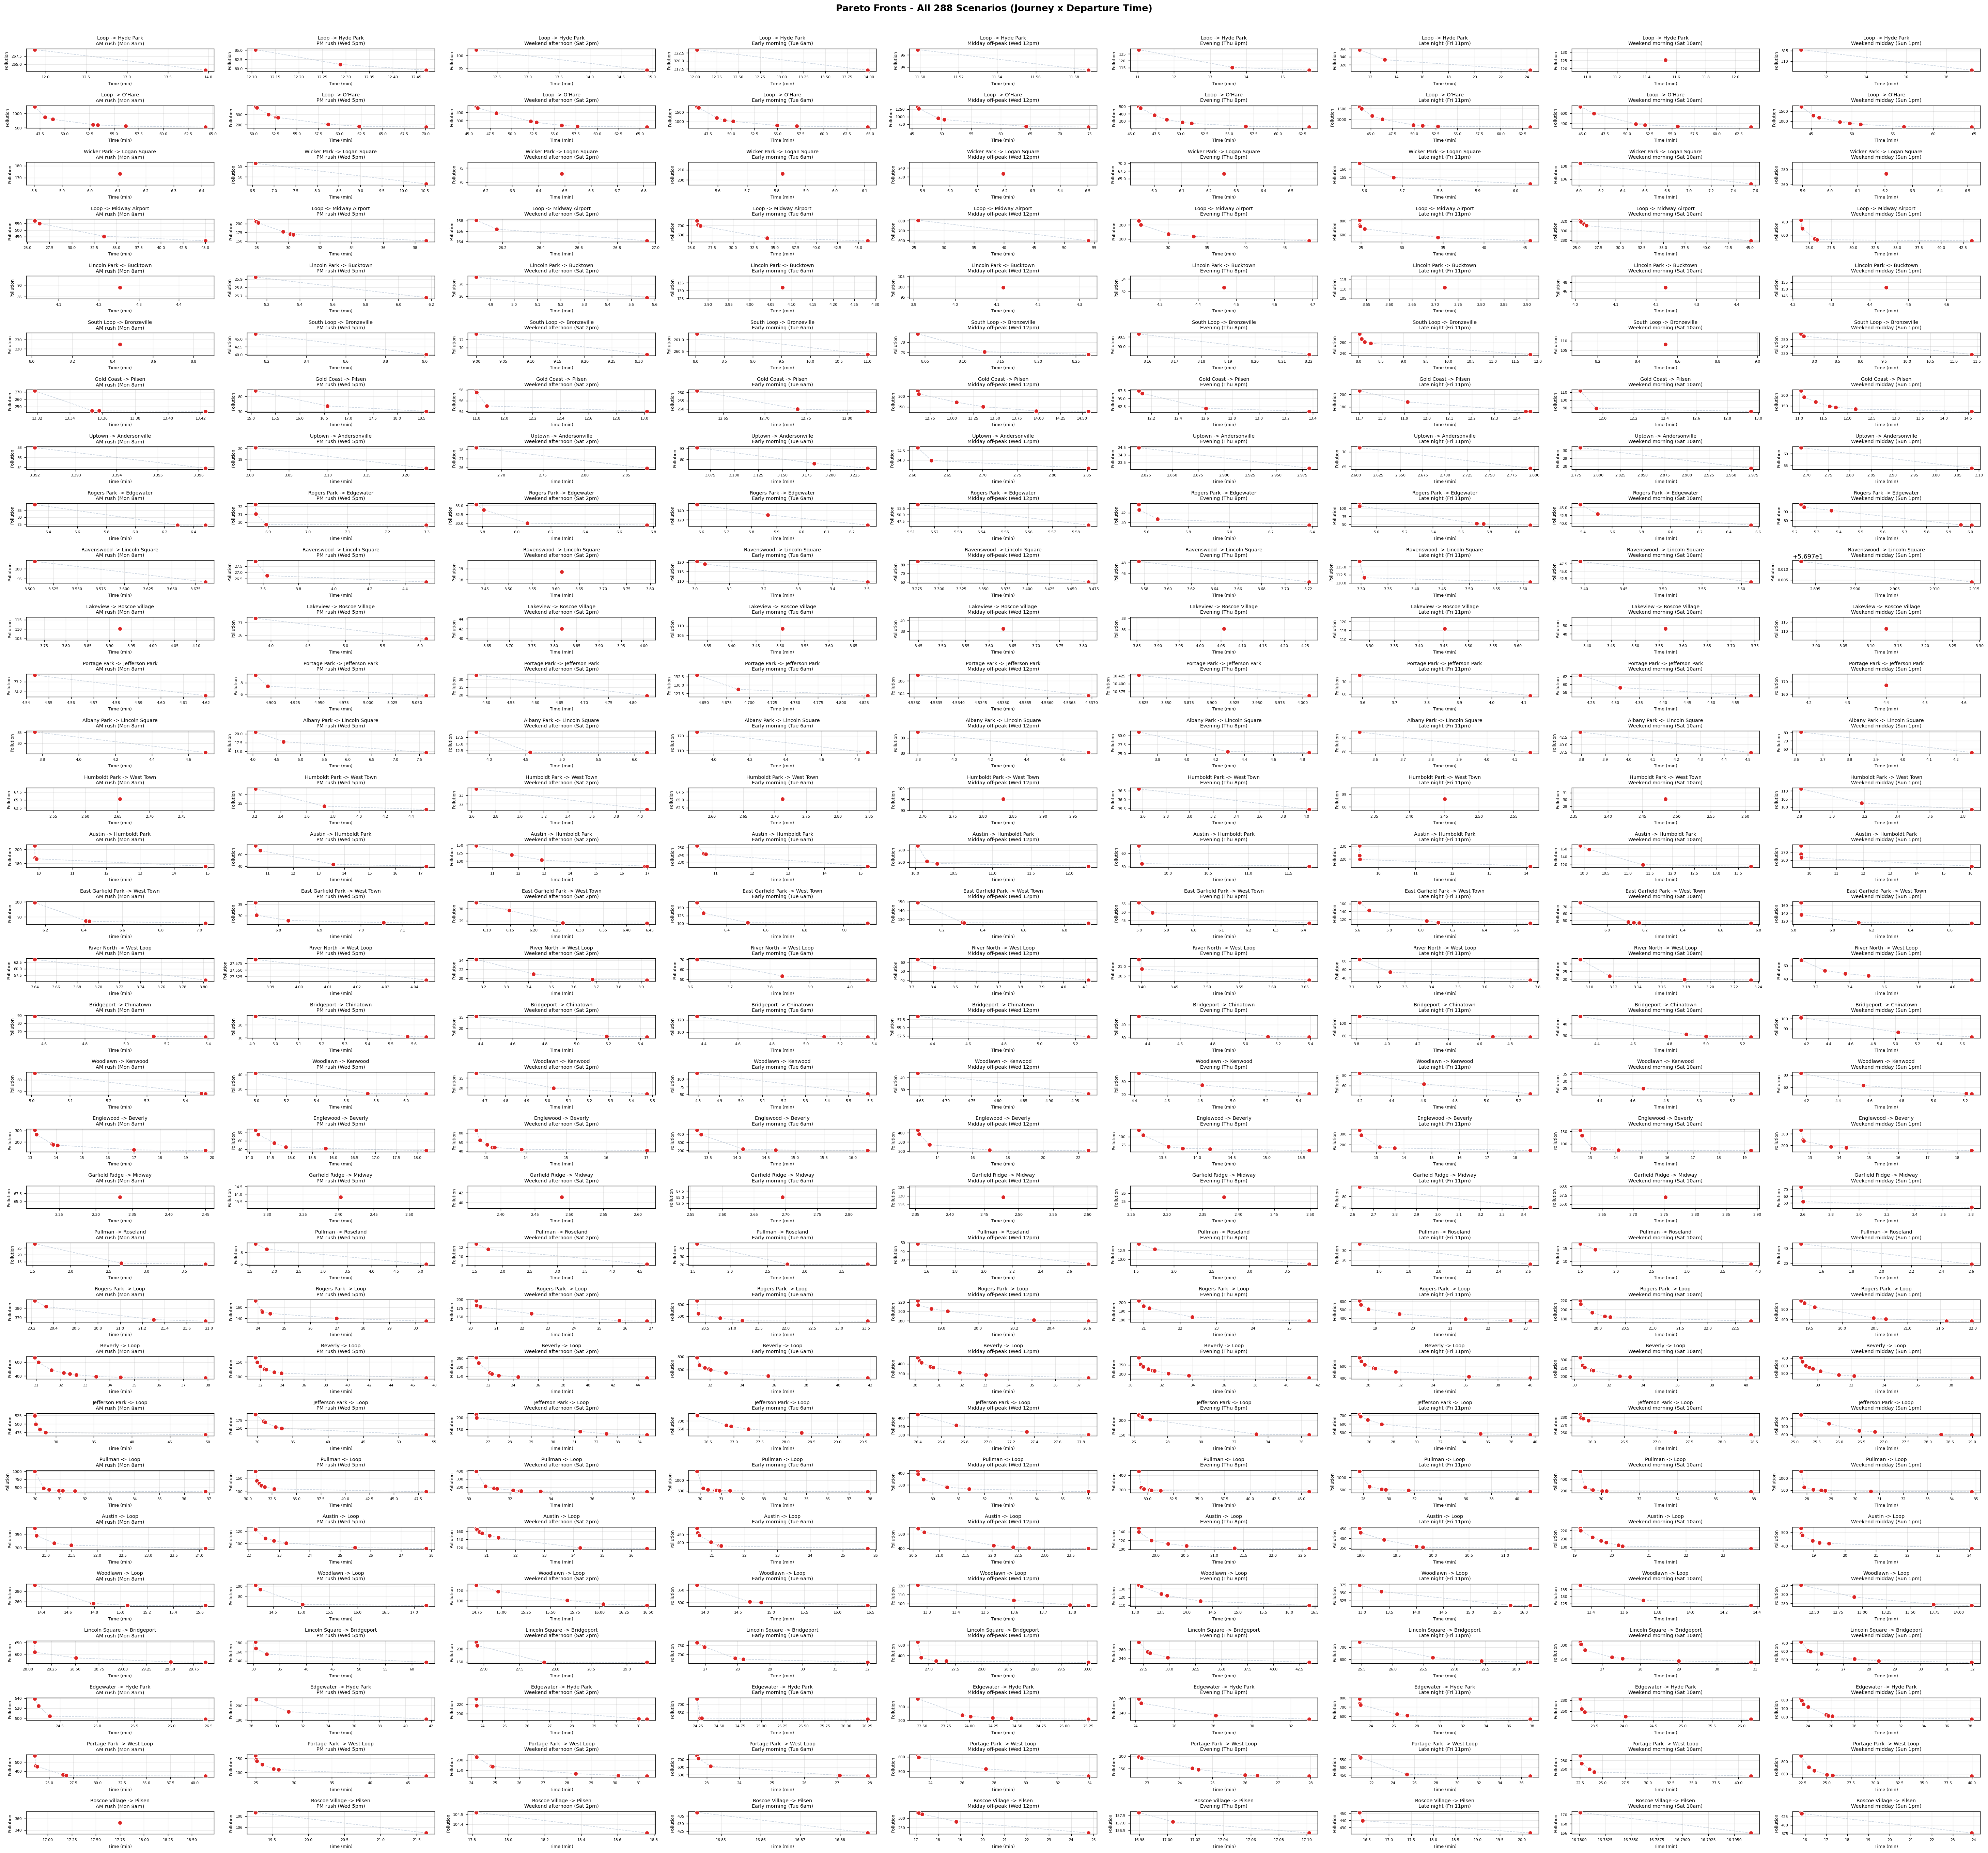

Saved: pareto_grid.png


In [11]:
n_journeys = len(JOURNEYS)
n_times = len(DEPARTURE_TIMES)
# Row height scales down for larger journey counts, so a 32-journey grid
# stays a manageable, actually-viewable file size instead of rendering
# 100+ inches tall at a fixed per-row height.
row_h = 3.2 if n_journeys <= 12 else max(1.3, 3.2 * 12 / n_journeys)
fig, axes = plt.subplots(n_journeys, n_times, figsize=(5*n_times, row_h*n_journeys))
fig.suptitle(f'Pareto Fronts - All {n_journeys*n_times} Scenarios (Journey x Departure Time)',
             fontsize=15, fontweight='bold', y=1.005)

journey_labels = [j[4] for j in JOURNEYS] # JOURNEYS = (o_lat,o_lon,d_lat,d_lon,label)
time_labels = [t[3] for t in DEPARTURE_TIMES] # DEPARTURE_TIMES = (hour,dow,month,label)

# One subplot per (journey, time) pair, showing that scenario's Pareto front
# as a time-vs-pollution scatter
for i, jl in enumerate(journey_labels):
    for j, tl in enumerate(time_labels):
        ax = axes[i, j] if n_journeys > 1 else axes[j]
        pareto = scenario_pareto[(jl, tl)]
        t_vals = [c['total_time_min'] for c in pareto]
        p_vals = [c['total_pollution'] for c in pareto]
        ax.scatter(t_vals, p_vals, color='#DC2626', s=50, zorder=3, edgecolors='white')
        if len(t_vals) > 1:
            # Dashed line just traces the front for readability, not a
            # claim about intermediate (non-existent) routes
            ax.plot(sorted(t_vals), [p for _,p in sorted(zip(t_vals,p_vals))],
                   color='#CBD5E1', lw=1, zorder=1, ls='--')
        ax.set_title(f'{jl}\n{tl}', fontsize=8)
        ax.set_xlabel('Time (min)', fontsize=7); ax.set_ylabel('Pollution', fontsize=7)
        ax.tick_params(labelsize=6); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/pareto_grid.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: pareto_grid.png')

---
## Section 6 - Evaluation vs Dijkstra Baseline (Aggregated)
### Objective 4: pollution reduction within an acceptable time increase

A single example scenario is really just an anecdote. Looking at the
distribution across all 288 gives a more defensible, statistically grounded answer.

 OBJECTIVE 4 - AGGREGATED ACROSS ALL SCENARIOS
Metric A - absolute cleanest route on the Pareto front (no time cap):
 Mean time increase: +27.9%  (range +0.0% to +216.4%)
 Mean pollution reduction: +23.2%  (range +0.0% to +68.1%)

Metric B - best pollution reduction achievable within a <=20% time budget
(this is what a real user selecting a "reasonable clean option" from the
Pareto front would actually get - arguably the more meaningful O4 metric,
since it respects the time constraint by construction):
 Mean time increase: +7.7%
 Mean pollution reduction: +18.3%(range +0.0% to +68.0%)

 Metric A - scenarios meeting BOTH targets: 49/288 (17%)
 Metric B - scenarios meeting pollution target within time budget: 133/288 (46%)
Target: pollution reduction >= 15% within time increase <= 20%


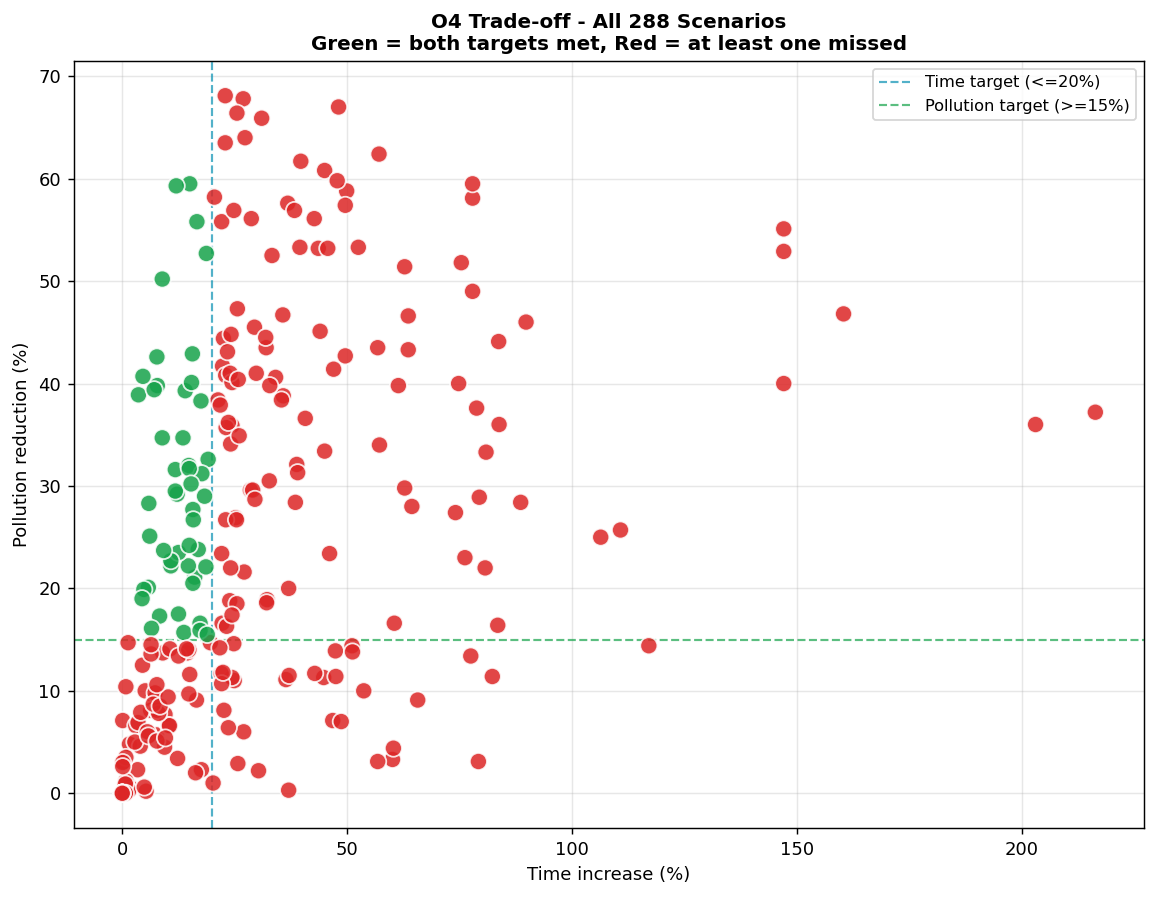

Saved: o4_aggregate.png


In [12]:
print('='*70)
print(' OBJECTIVE 4 - AGGREGATED ACROSS ALL SCENARIOS')
print('='*70)
n_scen = len(df_results)

# Metric A: compares the fastest route to the single cleanest point on the
# Pareto front, with no cap on how much extra time that costs
print('Metric A - absolute cleanest route on the Pareto front (no time cap):')
print(f" Mean time increase: {df_results['Time increase %'].mean():+.1f}%  "
      f"(range {df_results['Time increase %'].min():+.1f}% to {df_results['Time increase %'].max():+.1f}%)")
print(f" Mean pollution reduction: {df_results['Pollution reduction %'].mean():+.1f}%  "
      f"(range {df_results['Pollution reduction %'].min():+.1f}% to {df_results['Pollution reduction %'].max():+.1f}%)")

print()
print('Metric B - best pollution reduction achievable within a <=20% time budget')
print('(this is what a real user selecting a "reasonable clean option" from the')
print('Pareto front would actually get - arguably the more meaningful O4 metric,')
print('since it respects the time constraint by construction):')
print(f" Mean time increase: {df_results['Practical time increase %'].mean():+.1f}%")
print(f" Mean pollution reduction: {df_results['Practical pollution reduction %'].mean():+.1f}%"
      f"(range {df_results['Practical pollution reduction %'].min():+.1f}% to "
      f"{df_results['Practical pollution reduction %'].max():+.1f}%)")
print()

target_met = ((df_results['Time increase %'] <= 20) & (df_results['Pollution reduction %'] >= 15))
practical_target_met = (df_results['Practical pollution reduction %'] >= 15)
print(f' Metric A - scenarios meeting BOTH targets: {target_met.sum()}/{n_scen} ({target_met.mean()*100:.0f}%)')
print(f' Metric B - scenarios meeting pollution target within time budget: '
      f'{practical_target_met.sum()}/{n_scen} ({practical_target_met.mean()*100:.0f}%)')
print(f"Target: pollution reduction >= 15% within time increase <= 20%")

# With close to 300 scenarios a bar chart per scenario would be unreadable -
# a scatter plot, one point per scenario, colour-coded by whether it hits
# both targets, scales much better
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#16A34A' if m else '#DC2626' for m in target_met]
ax.scatter(df_results['Time increase %'], df_results['Pollution reduction %'],
          c=colors, s=90, edgecolors='white', linewidths=1, zorder=3, alpha=0.85)
ax.axvline(20, color='#0891B2', ls='--', lw=1.2, alpha=0.7, label='Time target (<=20%)')
ax.axhline(15, color='#16A34A', ls='--', lw=1.2, alpha=0.7, label='Pollution target (>=15%)')
ax.set_xlabel('Time increase (%)'); ax.set_ylabel('Pollution reduction (%)')
ax.set_title(f'O4 Trade-off - All {n_scen} Scenarios\n'
             f'Green = both targets met, Red = at least one missed',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/o4_aggregate.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: o4_aggregate.png')

---
## Section 8 - Sensitivity Analysis

Two questions worth asking of a multi-scenario design like this one:
1. Does time of day change the trade-off? (rush hour vs off-peak)
2. Does journey length/topology change route diversity?

In [13]:
# Question 1: does the fast/clean trade-off get bigger during rush hour?
print('Sensitivity - pollution reduction by departure time:')
by_time = df_results.groupby('Departure')['Pollution reduction %'].agg(['mean','std'])
display(by_time)

# Question 2: does route diversity depend on journey length/topology?
print('\nSensitivity - distinct routes found by journey:')
by_journey = df_results.groupby('Journey')['Distinct routes'].agg(['mean','min','max'])
display(by_journey)

print('')
print(' If rush-hour scenarios show LARGER pollution reduction, this suggests')
print(' congestion widens the fast/clean trade-off (slower arterial traffic')
print(' during peak hours makes the pollution cost of the fastest route higher).')
print(' If longer journeys (Loop->O\'Hare) show MORE distinct routes than short')
print(' ones (Wicker Park->Logan Square), this confirms the expected pattern:')
print(' route diversity scales with journey length and topological richness.')

Sensitivity - pollution reduction by departure time:


,mean,std
Departure,,
AM rush (Mon 8am),18.612500,20.044382
Early morning (Tue 6am),22.459375,20.362931
Evening (Thu 8pm),20.362500,18.925435
Late night (Fri 11pm),26.887500,20.583061
Midday off-peak (Wed 12pm),22.653125,18.586641
PM rush (Wed 5pm),26.109375,19.693217
Weekend afternoon (Sat 2pm),24.203125,19.097382
Weekend midday (Sun 1pm),26.534375,19.147822
Weekend morning (Sat 10am),21.031250,18.827904



Sensitivity - distinct routes found by journey:


,mean,min,max
Journey,,,
Albany Park -> Lincoln Square,2.333333,2,3
Austin -> Humboldt Park,4.000000,3,5
Austin -> Loop,7.333333,5,8
Beverly -> Loop,8.222222,7,9
Bridgeport -> Chinatown,3.111111,2,4
East Garfield Park -> West Town,4.222222,3,5
Edgewater -> Hyde Park,5.000000,4,8
Englewood -> Beverly,6.111111,5,7
Garfield Ridge -> Midway,1.333333,1,3



 If rush-hour scenarios show LARGER pollution reduction, this suggests
 congestion widens the fast/clean trade-off (slower arterial traffic
 during peak hours makes the pollution cost of the fastest route higher).
 If longer journeys (Loop->O'Hare) show MORE distinct routes than short
 ones (Wicker Park->Logan Square), this confirms the expected pattern:
 route diversity scales with journey length and topological richness.


---
## Section 9 - Map Visualization (All Journeys)

In [14]:
# Interactive map: switch between departure times (radio buttons) and toggle
# individual journeys (checkboxes) at the same time. Folium's built-in
# LayerControl/GroupedLayerControl can't do this on its own - two independent
# controls toggling overlapping layers give a union, not an intersection - so
# this uses a bit of custom JS that checks (time matches) AND (journey
# checked) directly against Folium's own generated layer variables.
import json as _json

m = folium.Map(location=[41.85, -87.68], zoom_start=10, tiles='CartoDB positron')

ROUTE_COLORS = {'Fastest': '#DC2626', 'Balanced': '#D97706', 'Cleanest': '#16A34A',
                'Mostly fast': '#F59E0B', 'Mostly clean': '#65A30D',
                'Fast-leaning': '#FB923C', 'Clean-leaning': '#84CC16',
                'Slightly fast': '#FBBF24', 'Slightly clean': '#A3E635'}

# One FeatureGroup per (time, journey) pair, all hidden initially - the
# custom JS below decides what's visible, not Folium's own show/hide.
layer_entries = []  # (js_var_name, time_label, journey_label)
for hour, dow, month, time_label in DEPARTURE_TIMES:
    for orig_node, dest_node, journey_label, o_ll, d_ll in journey_nodes:
        fg = folium.FeatureGroup(name=f"{time_label}::{journey_label}", show=False)
        pareto = scenario_pareto.get((journey_label, time_label), [])
        for c in pareto:
            coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in c['path']]
            color = ROUTE_COLORS.get(c['label'], '#6366F1')
            folium.PolyLine(coords, color=color, weight=3, opacity=0.75,
                            popup=f"{journey_label} - {c['label']} ({time_label}): "
                                  f"{c['total_time_min']:.1f} min, pollution {c['total_pollution']:.1f}"
                           ).add_to(fg)
        folium.CircleMarker([o_ll[0], o_ll[1]], radius=3, color='#2563EB', fill=True).add_to(fg)
        folium.CircleMarker([d_ll[0], d_ll[1]], radius=3, color='#111827', fill=True).add_to(fg)
        fg.add_to(m)
        layer_entries.append((fg.get_name(), time_label, journey_label))

# Build the lookup the JS filter will use: for each layer, which time and
# which journey it belongs to
time_labels_js = [t[3] for t in DEPARTURE_TIMES]
journey_labels_js = [j[4] for j in JOURNEYS]
layer_map_js = _json.dumps([{'var': v, 'time': t, 'journey': j} for v, t, j in layer_entries])

# Filter panel (top-right): one radio group for departure time, one set of
# checkboxes for journeys. updateMapLayers() re-evaluates visibility
# whenever either changes.
control_html = f'''
<div id="dual-filter-control" style="position:fixed;top:12px;right:12px;background:white;
     padding:12px 14px;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.3);
     z-index:1000;font-family:Arial;font-size:12px;max-height:80vh;overflow-y:auto;
     width:220px;">
  <b>Departure time</b><br>
  {"".join(f'<label><input type="radio" name="time_select" value="{t}" {"checked" if i==0 else ""} onchange="updateMapLayers()"> {t}</label><br>' for i,t in enumerate(time_labels_js))}
  <br><b>Journeys</b><br>
  {"".join(f'<label><input type="checkbox" class="journey_select" value="{j}" checked onchange="updateMapLayers()"> {j}</label><br>' for j in journey_labels_js)}
</div>
<script>
var mapLayers = {layer_map_js};
function updateMapLayers() {{
    var selectedTime = document.querySelector('input[name="time_select"]:checked').value;
    var checkedJourneys = Array.from(document.querySelectorAll('.journey_select:checked')).map(el => el.value);
    mapLayers.forEach(function(entry) {{
        var layer = window[entry['var']];
        if (!layer) return;
        var shouldShow = (entry['time'] === selectedTime) && (checkedJourneys.includes(entry['journey']));
        if (shouldShow) {{
            if (!{{MAP_VAR}}.hasLayer(layer)) {{ layer.addTo({{MAP_VAR}}); }}
        }} else {{
            if ({{MAP_VAR}}.hasLayer(layer)) {{ {{MAP_VAR}}.removeLayer(layer); }}
        }}
    }});
}}
document.addEventListener('DOMContentLoaded', updateMapLayers);
setTimeout(updateMapLayers, 500);
</script>
'''
control_html = control_html.replace('{MAP_VAR}', m.get_name())

m.get_root().html.add_child(folium.Element(control_html))

title_html = f'''
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
     background:white;padding:10px 18px;border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.25);z-index:1000;font-family:Arial;font-size:13px;">
  <b>Pareto-Optimal Routes - {len(JOURNEYS)} Journeys x {len(DEPARTURE_TIMES)} Departure Times</b><br>
  Pick a departure time and check/uncheck journeys (top-right panel)
</div>'''
m.get_root().html.add_child(folium.Element(title_html))

m.save('/content/multi_journey_map.html')
print('Map saved: multi_journey_map.html')
from IPython.display import IFrame
display(IFrame('/content/multi_journey_map.html', width='100%', height=550))

Map saved: multi_journey_map.html


---
## Section 10 - Summary

In [15]:
print('#'*70)
print('SUMMARY - Route Scoring & Multi-Objective Optimization')
print('#'*70)
# f-string summary pulling numbers straight from df_results / by_time /
# by_journey computed in the sections above, so this stays accurate if the
# experimental design (journey/time counts) changes
print(f"""
Experimental design: {len(JOURNEYS)} journeys x {len(DEPARTURE_TIMES)} departure times
                     = {len(df_results)} scenarios

Prediction mechanism: every edge is matched to its nearest real Chicago
Traffic Tracker segment (within 950m) and, where matched, the trained SR
expressions are called using THAT SEGMENT'S OWN historical average lag
values - a genuine per-edge call to fn_spd/fn_no2/fn_pm25. Unmatched edges
use the city-wide SR baseline with a gentle, secondary road-type adjustment
so fallback edges are not all identical to one another.

OBJECTIVE 3 - Pareto front (target >= 3 distinct routes per scenario):
  Scenarios meeting target: {(df_results['Distinct routes']>=3).sum()}/{len(df_results)}
  Mean distinct routes: {df_results['Distinct routes'].mean():.1f}

OBJECTIVE 4 - Evaluation vs Dijkstra baseline (target: pollution -15% within time +20%):
  Mean time increase: {df_results['Time increase %'].mean():+.1f}%
  Mean pollution reduction: {df_results['Pollution reduction %'].mean():+.1f}%
  Scenarios meeting both targets: {target_met.sum()}/{len(df_results)}

Sensitivity findings:
  Pollution reduction varies by departure time (see Section 8 breakdown) -
  {by_time['mean'].idxmax()} shows the largest average reduction.
  Route diversity varies by journey (see Section 8 breakdown) -
  {by_journey['mean'].idxmax()} shows the most distinct routes on average.
""")

# Quick check that all the expected output files actually got written
for fname in ['pareto_grid.png', 'o4_aggregate.png', 'multi_journey_map.html']:
    e = os.path.exists(f'/content/{fname}')
    print(f' {"OK" if e else "MISSING"} /content/{fname}')

######################################################################
SUMMARY - Route Scoring & Multi-Objective Optimization
######################################################################

Experimental design: 32 journeys x 9 departure times
                     = 288 scenarios

Prediction mechanism: every edge is matched to its nearest real Chicago
Traffic Tracker segment (within 950m) and, where matched, the trained SR
expressions are called using THAT SEGMENT'S OWN historical average lag
values - a genuine per-edge call to fn_spd/fn_no2/fn_pm25. Unmatched edges
use the city-wide SR baseline with a gentle, secondary road-type adjustment
so fallback edges are not all identical to one another.

OBJECTIVE 3 - Pareto front (target >= 3 distinct routes per scenario):
  Scenarios meeting target: 196/288
  Mean distinct routes: 4.0

OBJECTIVE 4 - Evaluation vs Dijkstra baseline (target: pollution -15% within time +20%):
  Mean time increase: +27.9%
  Mean pollution reduction: +23.2